In [1]:
# --- Core libraries ---
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import geopandas as gpd
from shapely.geometry import Point
import plotly.express as px # for interactive plots

# --- Scikit-learn: model training, preprocessing, CV, evaluation ---
from sklearn.model_selection import (
    GroupKFold,
    RandomizedSearchCV,
    cross_validate,
    train_test_split,
    GridSearchCV
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    balanced_accuracy_score,
    roc_auc_score,
    make_scorer,
    ConfusionMatrixDisplay
)
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import BallTree

# --- XGBoost ---
from xgboost import XGBRegressor, plot_tree, plot_importance
import xgboost  # Optional: useful for checking version

# --- Other ---
from haversine import haversine
import scipy.stats as stats
import gstools as gs #variogram modeling
from sklearn.metrics import pairwise_distances # for distance calculations
from scipy.cluster.hierarchy import linkage, dendrogram #for hierarchical clustering dendrogram
from tabulate import tabulate # for pretty printing tables

In [2]:
print("Current working directory:", os.getcwd())

#load in 
df_raw = pd.read_csv("../../../data/finaldatasets/testdata/XGBoost.csv")  # for variogram, etc.
df = df_raw.copy()  # working copy for feature engineering + model prep
print(list(df.columns))

Current working directory: /home/sebastian-dohne/Documents/FinalProject/code/analysis/kagglefeatureengineering
['id', 'Data.ID', 'Location', 'State.Region.County.Province', 'Country', 'Continent', 'Latitude..N.S.', 'Longitude..E.W.', 'Conversion.for.latitude', 'Conversion.for.longitude', 'Location.source', 'Observation.period', 'Wheat.Type', 'Crop.variety', 'Tillage.type', 'Treatment', 'Grain.yield..tons.ha.1.', 'Mean.annual.temperature..Â.C.', 'Mean.annual.precipitation..mm.', 'Soil.type', 'Sand', 'Silt', 'Clay', 'Soil.organic.carbon..g.C.kg.1.', 'Soil.pH', 'N.rate..kg.N.ha.1.', 'P.rate..kg.P.ha.1.', 'Pest.prescence....64', 'rainfed_start_date', 'irr_start_date', 'start_date', 'Soil_N', 'pr_irrigated', 'AEZ', 'Elevation', 'temp1', 'temp2', 'temp3', 'temp4', 'temp5', 'temp6', 'temp7', 'temp8', 'temp9', 'prc1', 'prc2', 'prc3', 'prc4', 'prc5', 'prc6', 'prc7', 'prc8', 'prc9', 'Irrigation.mm_clean', 'irrigation_applied', 'harvest_dayofyear', 'Treatment_Category', 'gdp', 'hdi', 'year', 'dry

/tmp/ipykernel_97055/683019795.py:4: DtypeWarning: Columns (6,7,13,14,15,19,27,56) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv("../../../data/finaldatasets/testdata/XGBoost.csv")  # for variogram, etc.


Data summary function

In [3]:
def summarize_dataframe(df):
    """
    Prints a summary of the DataFrame's columns including:
    - dtype
    - count of non-null values
    - % completeness
    - number of unique values
    Output is printed in GitHub-style markdown table.
    """
    def summarize_column(col_data):
        numeric_data = pd.to_numeric(col_data, errors='coerce')
        is_numeric = numeric_data.notna().sum() > 0
        return {
            "dtype": col_data.dtype,
            "count": col_data.notna().sum(),
            "pct_complete": round(col_data.notna().mean() * 100, 1),
            "n_unique": col_data.nunique(dropna=True)
        }

    summary_long = (
        pd.DataFrame([
            {"variable": col, **summarize_column(df[col])}
            for col in df.columns
        ])
        .sort_values(by="pct_complete", ascending=False)
        .reset_index(drop=True)
    )

    print(tabulate(summary_long, headers="keys", tablefmt="github", showindex=False))

In [7]:
# Define groups of columns to drop
LOCATION_COLS = [
    "id", "Data.ID", "Location", "State.Region.County.Province", "Country", "Continent",
    "Latitude..N.S.", "Longitude..E.W.",
    "Location.source", "Observation.period", "X", "Y", "unit_code"
]

# "Conversion.for.latitude", "Conversion.for.longitude"
HIGH_CARDINALITY_COLS = [
    "Treatment.type", "Emissions..yes.no.",
    "Irrigation..mm.", "Harvesting.date.1","Pest.severity.score.......66",
    "Agricultural_Use_–_Other_Pesticides_nes_(t)","Agricultural_Use_–_Rodenticides_(t)", 
    "irr_end_date", "end_date", "rainfed_end_date"
]


COLLINEAR_COLS = [
    "harvest_month", "harvest_date_clean", "harvest_week",
    "Planting.date", "Planting_Month", "Planting.date.1", "Planting_Week"
]

# These columns are used for testing purposes
TESTCOLUMNS = [
    "Crop.variety", "N.type", "gdp", "hdi", "P.rate..kg.P.ha.1.",
    "dryspells(5days)", "drydays(annualsum)", "irr_start_date", "rainfed_start_date",
    "Mean.annual.precipitation..mm.", "irrigation_applied",
    "Irrigation.mm_clean", "Soil.type", "harvest_dayofyear", "Treatment_Category",
    "Tillage.type", "Treatment", "Mean.annual.temperature..Â.C.", "start_date"
]


# Combine all columns to drop into a single set (to avoid duplicates)
COLUMNS_TO_DROP = set(LOCATION_COLS + HIGH_CARDINALITY_COLS + COLLINEAR_COLS + TESTCOLUMNS)

# Drop all listed columns if they exist in the DataFrame
df_cleaned = df.drop(columns=[col for col in COLUMNS_TO_DROP if col in df.columns])

# Optional: Review dropped and remaining columns
print("Original shape:", df.shape)
print("Shape after dropping:", df_cleaned.shape)
print("Dropped columns:", [col for col in COLUMNS_TO_DROP if col in df.columns])
print("Remaining columns:", df_cleaned.columns.tolist())

# Drop columns with less than 20% completeness
df_cleaned = df_cleaned.loc[:, df_cleaned.count() / len(df_cleaned) >= 0.2]

# Drop unnamed columns and rows with NaN in the target variable
df_cleaned = df_cleaned.loc[:, ~df_cleaned.columns.str.contains('^Unnamed')]
df_cleaned = df_cleaned.dropna(subset=["Grain.yield..tons.ha.1."])


Original shape: (69430, 69)
Shape after dropping: (69430, 41)
Dropped columns: ['Mean.annual.temperature..Â.C.', 'Longitude..E.W.', 'Continent', 'P.rate..kg.P.ha.1.', 'harvest_dayofyear', 'hdi', 'Treatment', 'Country', 'gdp', 'State.Region.County.Province', 'Irrigation.mm_clean', 'Treatment_Category', 'Latitude..N.S.', 'Tillage.type', 'Observation.period', 'Soil.type', 'dryspells(5days)', 'rainfed_start_date', 'Location.source', 'Data.ID', 'Crop.variety', 'irrigation_applied', 'start_date', 'drydays(annualsum)', 'id', 'Mean.annual.precipitation..mm.', 'irr_start_date', 'Location']
Remaining columns: ['Conversion.for.latitude', 'Conversion.for.longitude', 'Wheat.Type', 'Grain.yield..tons.ha.1.', 'Sand', 'Silt', 'Clay', 'Soil.organic.carbon..g.C.kg.1.', 'Soil.pH', 'N.rate..kg.N.ha.1.', 'Pest.prescence....64', 'Soil_N', 'pr_irrigated', 'AEZ', 'Elevation', 'temp1', 'temp2', 'temp3', 'temp4', 'temp5', 'temp6', 'temp7', 'temp8', 'temp9', 'prc1', 'prc2', 'prc3', 'prc4', 'prc5', 'prc6', 'prc7'

In [8]:
summarize_dataframe(df_cleaned)

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| Conversion.for.latitude                               | float64 |   69430 |          100   |        237 |
| prc3                                                  | float64 |   69430 |          100   |        272 |
| Conversion.for.longitude                              | float64 |   69430 |          100   |        237 |
| temp7                                                 | float64 |   69430 |          100   |        281 |
| temp8                                                 | float64 |   69430 |          100   |        282 |
| temp9                                                 | float64 |   69430 |          100   |        282 |
| prc1                                                  | float64 |   69430 |          100   |        268 |
| prc2                      

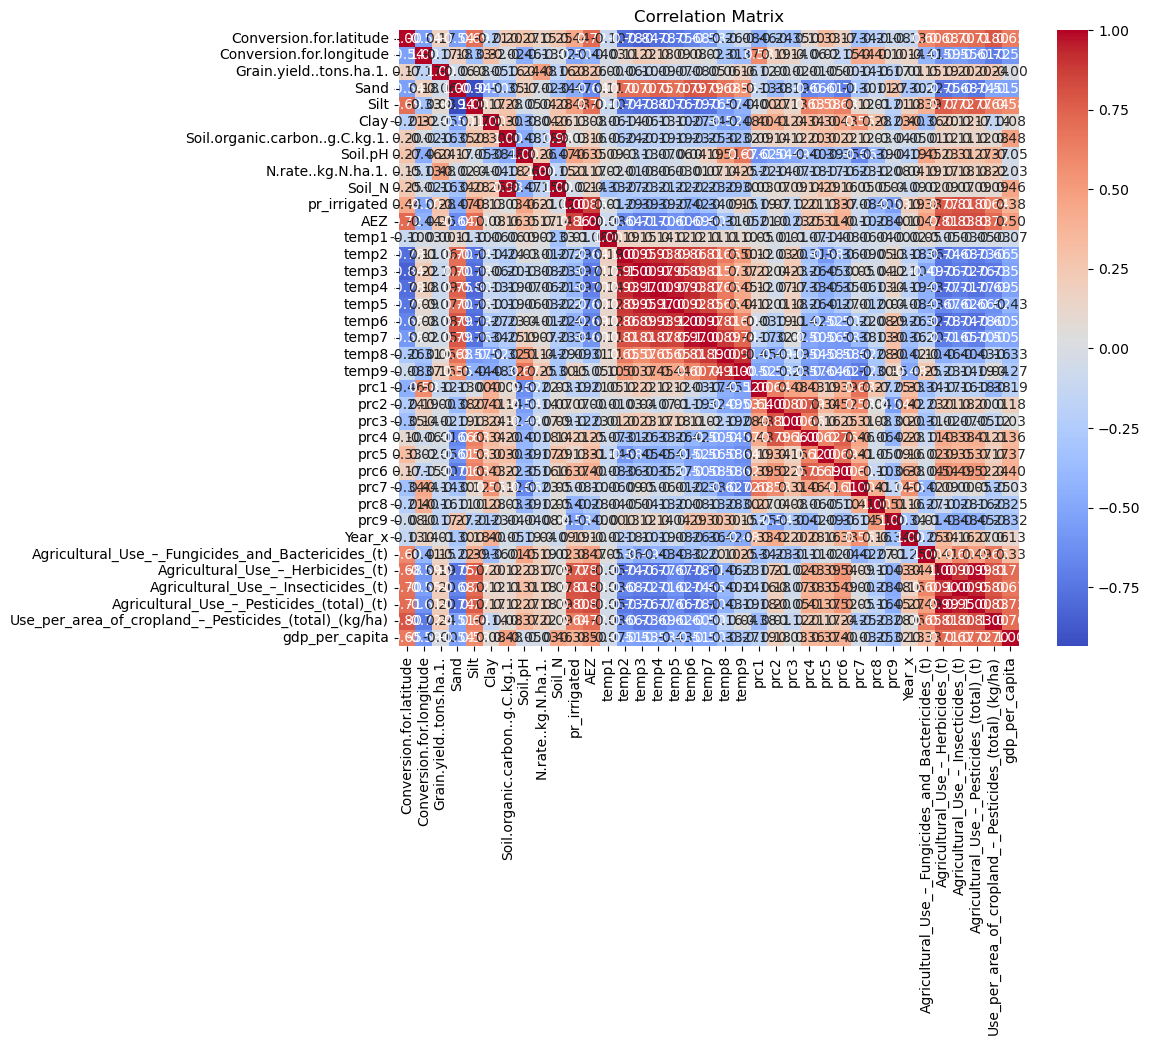

In [6]:
# Select only float columns for correlation
# Select only float columns except the target variable
float_cols = df_cleaned.select_dtypes(include=['float64', 'float32'])
corr_matrix = float_cols.corr(method='pearson')

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

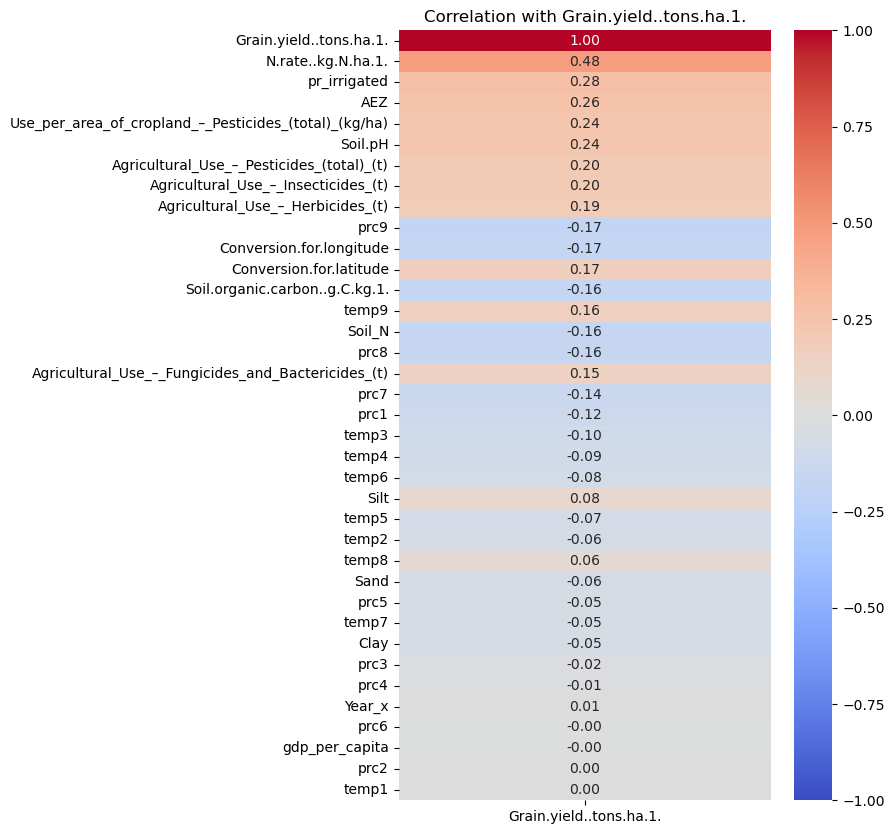

,Grain.yield..tons.ha.1.
Grain.yield..tons.ha.1.,1.000000
N.rate..kg.N.ha.1.,0.483241
pr_irrigated,0.279783
AEZ,0.262321
Use_per_area_of_cropland_–_Pesticides_(total)_(kg/ha),0.238002
Soil.pH,0.235719
Agricultural_Use_–_Pesticides_(total)_(t),0.201406
Agricultural_Use_–_Insecticides_(t),0.200305
Agricultural_Use_–_Herbicides_(t),0.192437
prc9,-0.174616


In [9]:
def plot_feature_correlations(df, target_col, method='pearson', sort_abs=True, figsize=(6, 10)):
    # Select numeric columns (float types)
    float_df = df.select_dtypes(include=['float32', 'float64'])
    
    if target_col not in float_df.columns:
        raise ValueError(f"Target column '{target_col}' is not numeric or not in DataFrame.")
    
    # Compute correlation matrix
    corr = float_df.corr(method=method)
    
    # Extract and sort correlation with target
    target_corr = corr[[target_col]]
    if sort_abs:
        target_corr = target_corr.reindex(target_corr[target_col].abs().sort_values(ascending=False).index)
    else:
        target_corr = target_corr.sort_values(by=target_col, ascending=False)
    
    # Plot
    plt.figure(figsize=figsize)
    sns.heatmap(target_corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
    plt.title(f"Correlation with {target_col}")
    plt.show()
    
    return target_corr


plot_feature_correlations(df_cleaned, "Grain.yield..tons.ha.1.")

/tmp/ipykernel_27251/3992205500.py:11: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



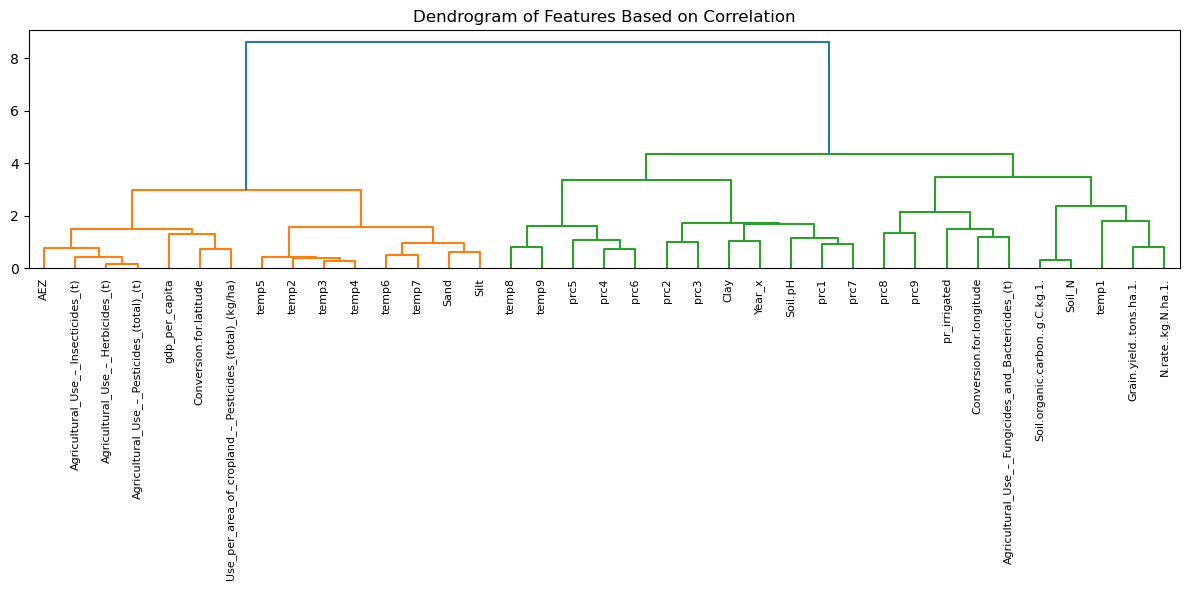

In [39]:
# Keep just the float columns
float_cols = df_cleaned.select_dtypes(include=['float64', 'float32'])

# Compute absolute correlation matrix
corr_matrix = float_cols.corr().abs()

# Convert correlation to distance
distance_matrix = 1 - corr_matrix

# Perform hierarchical clustering (linkage requires condensed distance matrix)
linked = linkage(distance_matrix, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked, labels=distance_matrix.columns, leaf_rotation=90)
plt.title("Dendrogram of Features Based on Correlation")
plt.tight_layout()
plt.show()